# 04 — Advanced Analyses

**PM Accelerator — Advanced track**  
**Input:** `data/processed/weather_cleaned.csv`

---

## What this notebook covers (assessment checklist)

| Requirement | Section |
|-------------|---------|
| Anomaly detection | 2 |
| Climate / regional patterns | 3 |
| Air quality vs weather | 4 |
| Feature importance (multiple methods) | 5 |
| Spatial / geographic patterns | 6–7 |

These analyses go beyond basic EDA + one forecast model.


## 1. Imports & load cleaned data


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

ROOT = Path("..").resolve()
CLEAN_PATH = ROOT / "data" / "processed" / "weather_cleaned.csv"
OUT_DIR = ROOT / "outputs" / "advanced"
OUT_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

df = pd.read_csv(CLEAN_PATH, low_memory=False)
df["last_updated"] = pd.to_datetime(df["last_updated"])
df["date"] = pd.to_datetime(df["date"])
df["abs_latitude"] = df["latitude"].abs()

print("Shape:", df.shape)
print("Time range:", df["last_updated"].min(), "->", df["last_updated"].max())
df.head(2)


Shape: (153775, 38)
Time range: 2024-05-16 01:45:00 -> 2026-07-17 19:00:00


,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,...,sunset,moonrise,moonset,moon_phase,moon_illumination,date,year,month,day_of_week,abs_latitude
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338,...,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,3,34.52
1,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 18:30:00,22.0,Patchy rain nearby,7.2,318,...,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55,2024-05-16,2024,5,3,34.52


## 1b. Continent mapping (for climate & geography)

We map countries to continents so we can compare **regions**, not only cities.
Unknown / special cases fall into Other.


In [2]:
# Compact country -> continent map for this dataset
ASIA = {
    "Afghanistan","Armenia","Azerbaijan","Bahrain","Bangladesh","Bhutan","Brunei","Cambodia",
    "China","Georgia","India","Indonesia","Iran","Iraq","Israel","Japan","Jordan","Kazakhstan",
    "Kuwait","Kyrgyzstan","Laos","Lebanon","Malaysia","Maldives","Mongolia","Myanmar","Nepal",
    "North Korea","Oman","Pakistan","Philippines","Qatar","Saudi Arabia","Singapore","South Korea",
    "Sri Lanka","Syria","Taiwan","Tajikistan","Thailand","Timor-Leste","Turkey","Turkmenistan",
    "United Arab Emirates","Uzbekistan","Vietnam","Yemen","Palestine","Hong Kong","Macao",
}
EUROPE = {
    "Albania","Andorra","Austria","Belarus","Belgium","Bosnia and Herzegovina","Bulgaria","Croatia",
    "Cyprus","Czech Republic","Czechia","Denmark","Estonia","Finland","France","Germany","Greece",
    "Hungary","Iceland","Ireland","Italy","Kosovo","Latvia","Liechtenstein","Lithuania","Luxembourg",
    "Malta","Moldova","Monaco","Montenegro","Netherlands","North Macedonia","Norway","Poland",
    "Portugal","Romania","Russia","San Marino","Serbia","Slovakia","Slovenia","Spain","Sweden",
    "Switzerland","Ukraine","United Kingdom","Vatican City","Scotland","Wales","England",
}
AFRICA = {
    "Algeria","Angola","Benin","Botswana","Burkina Faso","Burundi","Cameroon","Cape Verde",
    "Central African Republic","Chad","Comoros","Congo","DR Congo","Djibouti","Egypt",
    "Equatorial Guinea","Eritrea","Eswatini","Ethiopia","Gabon","Gambia","Ghana","Guinea",
    "Guinea-Bissau","Ivory Coast","Kenya","Lesotho","Liberia","Libya","Madagascar","Malawi",
    "Mali","Mauritania","Mauritius","Morocco","Mozambique","Namibia","Niger","Nigeria","Rwanda",
    "Sao Tome and Principe","Senegal","Seychelles","Sierra Leone","Somalia","South Africa",
    "South Sudan","Sudan","Tanzania","Togo","Tunisia","Uganda","Zambia","Zimbabwe",
    "Republic of the Congo","Democratic Republic of the Congo","Cote d'Ivoire","Swaziland",
}
NORTH_AMERICA = {
    "Antigua and Barbuda","Bahamas","Barbados","Belize","Canada","Costa Rica","Cuba","Dominica",
    "Dominican Republic","El Salvador","Grenada","Guatemala","Haiti","Honduras","Jamaica","Mexico",
    "Nicaragua","Panama","Saint Kitts and Nevis","Saint Lucia","Saint Vincent and the Grenadines",
    "Trinidad and Tobago","United States of America","USA","United States",
}
SOUTH_AMERICA = {
    "Argentina","Bolivia","Brazil","Chile","Colombia","Ecuador","Guyana","Paraguay","Peru",
    "Suriname","Uruguay","Venezuela",
}
OCEANIA = {
    "Australia","Fiji","Fiji Islands","Kiribati","Marshall Islands","Micronesia","Nauru",
    "New Zealand","Palau","Papua New Guinea","Samoa","Solomon Islands","Tonga","Tuvalu","Vanuatu",
}


def to_continent(country: str) -> str:
    c = str(country).strip()
    if c in ASIA or c.startswith("Korea"):
        return "Asia"
    if c in EUROPE:
        return "Europe"
    if c in AFRICA:
        return "Africa"
    if c in NORTH_AMERICA:
        return "North America"
    if c in SOUTH_AMERICA:
        return "South America"
    if c in OCEANIA:
        return "Oceania"
    return "Other"


df["continent"] = df["country"].map(to_continent)
print(df["continent"].value_counts())
print("Other countries sample:", df.loc[df["continent"] == "Other", "country"].unique()[:20])


continent
Africa           38668
Asia             37499
Europe           35879
North America    18075
Oceania          10255
South America     9440
Other             3959
Name: count, dtype: int64
Other countries sample: <ArrowStringArray>
[               'Brunei Darussalam',                          'Bélgica',
     'Democratic Republic of Congo',                          'Estonie',
                             'Inde',                            'Jemen',
                          'Komoren',                      'Kyrghyzstan',
 'Lao People's Democratic Republic',                          'Letonia',
                        'Macedonia',                          'Malásia',
                         'Marrocos',                          'Mexique',
                          'Polônia',  'Saint-Vincent-et-les-Grenadines',
                    'Saudi Arabien',               'Seychelles Islands',
                         'Südkorea',                     'Turkménistan']
Length: 20, dtype: str


## 2. Anomaly detection

### Why
Day 1 used domain caps for impossible values. Here we detect **unusual but possible** weather snapshots using Isolation Forest.

### Idea
Isolation Forest isolates rare points faster than normal ones.
`contamination` ≈ expected fraction of anomalies.

### What we analyze
Temperature, wind, pressure, precip, humidity, PM2.5 — jointly.


In [3]:
anomaly_cols = [
    "temperature_celsius",
    "wind_kph",
    "pressure_mb",
    "precip_mm",
    "humidity",
    "air_quality_PM2.5",
]

# Sample for speed (Isolation Forest on 150k is fine, but sample keeps notebook snappy)
anom_sample = df[anomaly_cols].sample(n=min(40000, len(df)), random_state=RANDOM_STATE).copy()

iso = IsolationForest(
    n_estimators=200,
    contamination=0.02,  # flag ~2% as anomalies
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
anom_sample["anomaly_label"] = iso.fit_predict(anom_sample[anomaly_cols])  # -1 = anomaly
anom_sample["is_anomaly"] = anom_sample["anomaly_label"] == -1

n_anom = int(anom_sample["is_anomaly"].sum())
print(f"Flagged anomalies: {n_anom} / {len(anom_sample)} ({100*n_anom/len(anom_sample):.2f}%)")

# Compare normal vs anomaly averages
compare = anom_sample.groupby("is_anomaly")[anomaly_cols].mean().T
compare.columns = ["normal_mean", "anomaly_mean"]
compare["diff"] = compare["anomaly_mean"] - compare["normal_mean"]
display(compare.round(2))

# Attach a few anomalies back with location context for storytelling
idx = anom_sample.index
df_anom = df.loc[idx, ["country", "location_name", "last_updated", "continent"] + anomaly_cols].copy()
df_anom["is_anomaly"] = anom_sample["is_anomaly"].values
top_anom = df_anom[df_anom["is_anomaly"]].nlargest(10, "air_quality_PM2.5")
print("Example anomalies (highest PM2.5 among flagged):")
display(top_anom[["country", "location_name", "last_updated", "temperature_celsius", "wind_kph", "precip_mm", "air_quality_PM2.5"]])


Flagged anomalies: 800 / 40000 (2.00%)


,normal_mean,anomaly_mean,diff
temperature_celsius,21.30,23.56,2.26
wind_kph,12.55,19.67,7.12
pressure_mb,1014.18,1007.23,-6.94
precip_mm,0.11,1.36,1.25
humidity,67.21,53.15,-14.06
air_quality_PM2.5,21.32,127.64,106.32


Example anomalies (highest PM2.5 among flagged):


,country,location_name,last_updated,temperature_celsius,wind_kph,precip_mm,air_quality_PM2.5
29338,Chile,Santiago,2024-06-07 10:00:00,9.2,6.8,0.0,1406.3
29389,Chile,Santiago,2024-07-30 08:15:00,10.7,7.9,0.0,1188.4
29363,Chile,Santiago,2024-07-02 09:15:00,4.1,6.1,0.0,1116.0
29331,Chile,Santiago,2024-05-31 10:15:00,8.0,6.8,0.0,1018.7
29384,Chile,Santiago,2024-07-25 08:15:00,7.4,4.0,0.0,939.8
29370,Chile,Santiago,2024-07-09 08:45:00,-0.8,6.1,0.0,930.5
29337,Chile,Santiago,2024-06-06 10:00:00,9.0,3.6,0.0,920.8
29361,Chile,Santiago,2024-06-30 09:30:00,4.2,3.6,0.0,848.2
29376,Chile,Santiago,2024-07-15 09:00:00,6.8,3.6,0.0,844.9
29358,Chile,Santiago,2024-06-27 09:15:00,4.4,3.6,0.0,784.2


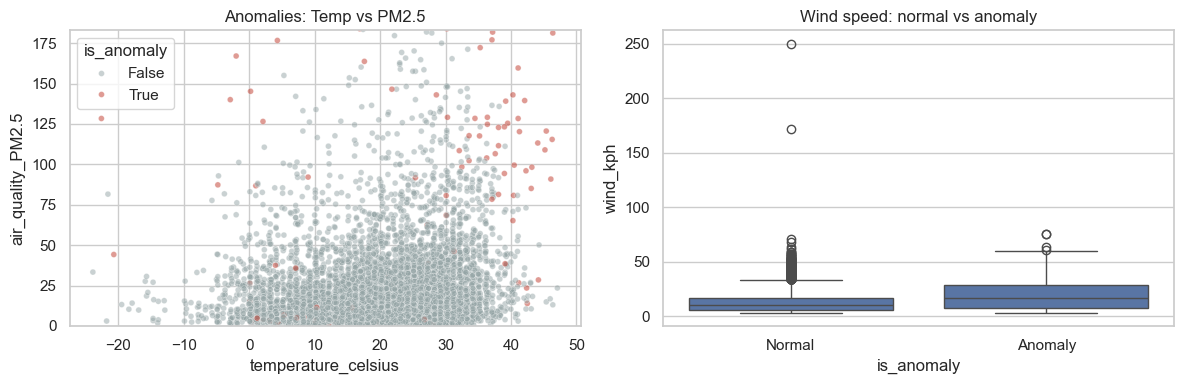

In [4]:
# Visual: temperature vs PM2.5, highlight anomalies
plot_df = anom_sample.sample(n=min(8000, len(anom_sample)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.scatterplot(
    data=plot_df, x="temperature_celsius", y="air_quality_PM2.5",
    hue="is_anomaly", palette={False: "#95a5a6", True: "#c0392b"},
    alpha=0.5, s=18, ax=axes[0], legend=True,
)
axes[0].set_title("Anomalies: Temp vs PM2.5")
axes[0].set_ylim(0, min(400, plot_df["air_quality_PM2.5"].quantile(0.99) * 1.2))

sns.boxplot(data=anom_sample, x="is_anomaly", y="wind_kph", ax=axes[1])
axes[1].set_title("Wind speed: normal vs anomaly")
axes[1].set_xticklabels(["Normal", "Anomaly"])

plt.tight_layout()
fig.savefig(OUT_DIR / "01_anomaly_detection.png", dpi=150, bbox_inches="tight")
plt.show()

anom_sample.to_csv(OUT_DIR / "anomaly_sample_flags.csv", index=False)


## 3. Climate analysis — regional patterns

### Why
Long-term / regional climate view: how temperature and precipitation differ by continent and season.


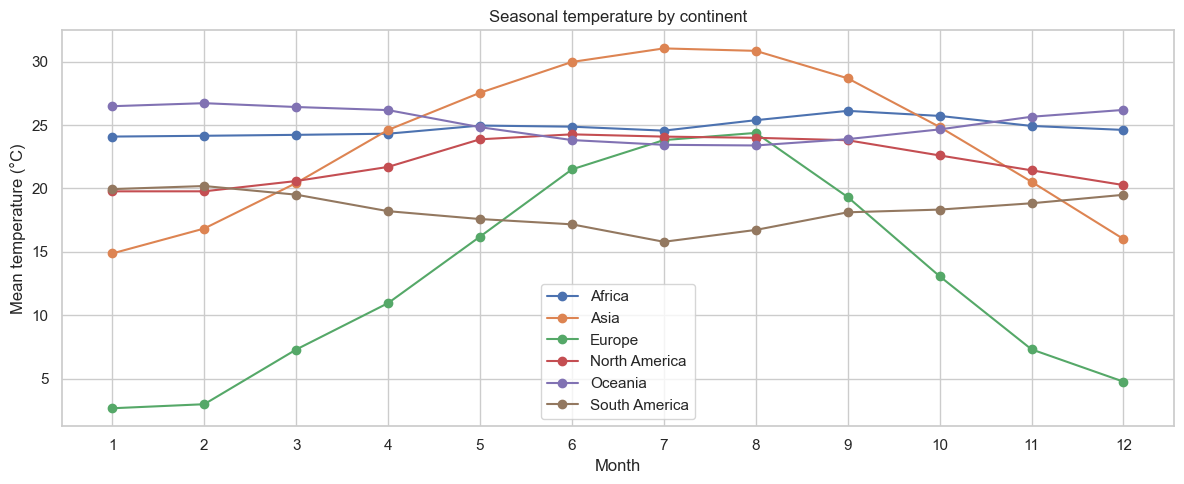

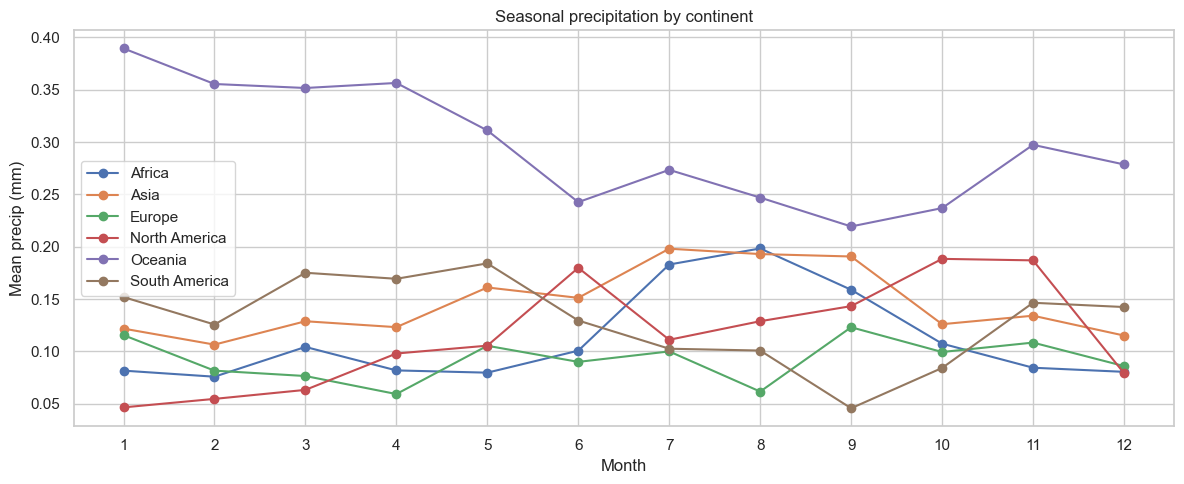

,mean_temp,temp_std,mean_precip,mean_pm25,n
continent,,,,,
Oceania,25.04,5.51,0.29,6.62,10255
Africa,24.83,5.31,0.11,23.91,38668
Asia,24.35,10.50,0.15,39.92,37499
Other,23.84,9.24,0.18,18.07,3959
North America,22.35,6.65,0.12,13.91,18075
South America,18.21,6.49,0.13,22.89,9440
Europe,13.53,9.84,0.09,15.47,35879


In [5]:
climate = (
    df.groupby(["continent", "month"], as_index=False)
    .agg(
        mean_temp=("temperature_celsius", "mean"),
        mean_precip=("precip_mm", "mean"),
        mean_humidity=("humidity", "mean"),
        n=("temperature_celsius", "count"),
    )
)

# Focus on main continents
main = climate[climate["continent"].isin(["Africa", "Asia", "Europe", "North America", "South America", "Oceania"])]

fig, ax = plt.subplots(figsize=(12, 5))
for cont, g in main.groupby("continent"):
    ax.plot(g["month"], g["mean_temp"], marker="o", label=cont)
ax.set_xticks(range(1, 13))
ax.set_title("Seasonal temperature by continent")
ax.set_xlabel("Month")
ax.set_ylabel("Mean temperature (°C)")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "02_climate_temp_by_continent.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(12, 5))
for cont, g in main.groupby("continent"):
    ax.plot(g["month"], g["mean_precip"], marker="o", label=cont)
ax.set_xticks(range(1, 13))
ax.set_title("Seasonal precipitation by continent")
ax.set_xlabel("Month")
ax.set_ylabel("Mean precip (mm)")
ax.legend()
plt.tight_layout()
fig.savefig(OUT_DIR / "03_climate_precip_by_continent.png", dpi=150, bbox_inches="tight")
plt.show()

continent_summary = (
    df.groupby("continent")
    .agg(
        mean_temp=("temperature_celsius", "mean"),
        temp_std=("temperature_celsius", "std"),
        mean_precip=("precip_mm", "mean"),
        mean_pm25=("air_quality_PM2.5", "mean"),
        n=("temperature_celsius", "count"),
    )
    .sort_values("mean_temp", ascending=False)
)
display(continent_summary.round(2))
continent_summary.to_csv(OUT_DIR / "continent_climate_summary.csv")


## 4. Environmental impact — air quality vs weather

### Why
Assessment: relate air quality to weather parameters (temp, humidity, wind, pressure, etc.).

### Expectation (physics intuition)
- Stronger wind can disperse pollution -> lower PM2.5
- Stagnant / humid conditions can trap pollutants


Correlation of weather features with PM2.5:


,corr_with_PM2.5
humidity,-0.221
cloud,-0.174
visibility_km,-0.118
precip_mm,-0.052
wind_kph,-0.046
pressure_mb,0.003
temperature_celsius,0.063


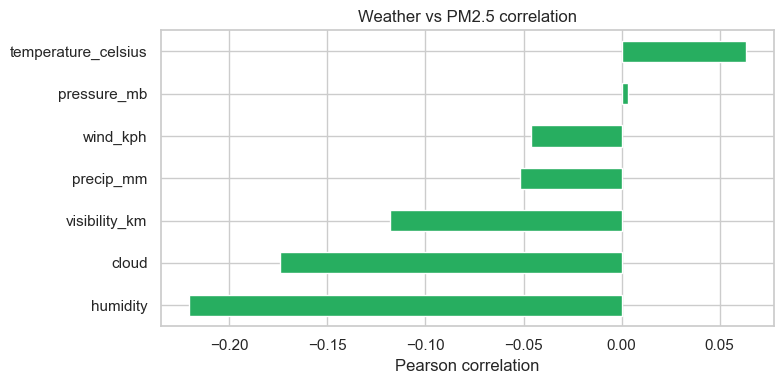

In [6]:
aqi_cols = [
    "air_quality_PM2.5",
    "air_quality_PM10",
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
]
weather_for_aqi = [
    "temperature_celsius",
    "humidity",
    "wind_kph",
    "pressure_mb",
    "cloud",
    "precip_mm",
    "visibility_km",
]

aqi_corr = df[aqi_cols + weather_for_aqi].corr()

# Focus: weather correlations with PM2.5
pm25_corr = aqi_corr["air_quality_PM2.5"][weather_for_aqi].sort_values()
print("Correlation of weather features with PM2.5:")
display(pm25_corr.round(3).to_frame("corr_with_PM2.5"))

fig, ax = plt.subplots(figsize=(8, 4))
pm25_corr.plot(kind="barh", ax=ax, color="#27ae60")
ax.set_title("Weather vs PM2.5 correlation")
ax.set_xlabel("Pearson correlation")
plt.tight_layout()
fig.savefig(OUT_DIR / "04_pm25_weather_correlation.png", dpi=150, bbox_inches="tight")
plt.show()


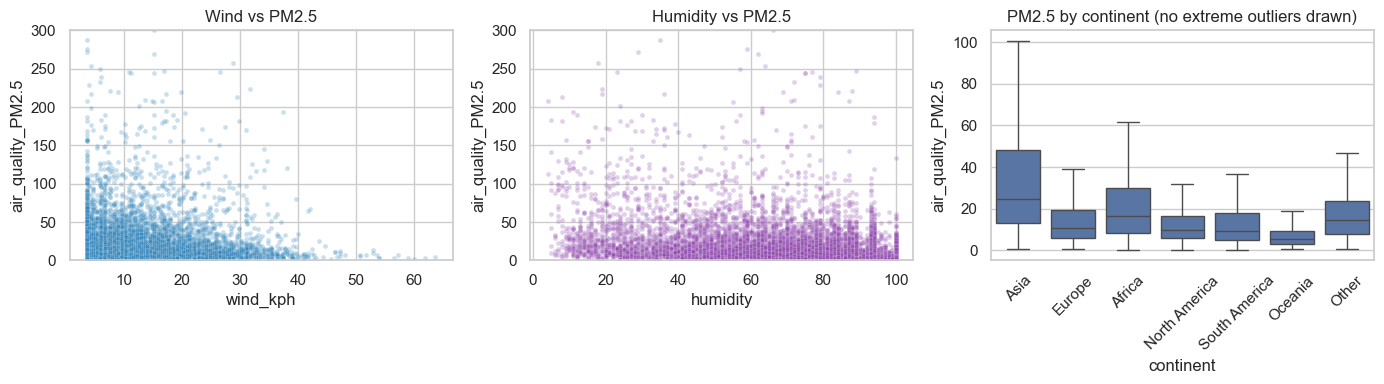

,air_quality_PM2.5,air_quality_PM10,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide
continent,,,,,,
Asia,39.92,90.25,750.48,69.25,27.70,23.87
Africa,23.91,58.31,336.37,59.05,5.48,5.19
South America,22.89,28.15,599.78,40.40,13.89,11.16
Other,18.07,22.82,412.07,55.93,8.27,7.20
Europe,15.47,20.50,283.68,56.94,17.70,5.31
North America,13.91,19.88,364.08,53.14,8.24,5.20
Oceania,6.62,10.32,148.41,38.22,1.34,0.15


In [7]:
sample = df.sample(n=8000, random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
sns.scatterplot(data=sample, x="wind_kph", y="air_quality_PM2.5", alpha=0.25, s=12, ax=axes[0], color="#2980b9")
axes[0].set_title("Wind vs PM2.5")
axes[0].set_ylim(0, 300)

sns.scatterplot(data=sample, x="humidity", y="air_quality_PM2.5", alpha=0.25, s=12, ax=axes[1], color="#8e44ad")
axes[1].set_title("Humidity vs PM2.5")
axes[1].set_ylim(0, 300)

sns.boxplot(data=df, x="continent", y="air_quality_PM2.5", ax=axes[2], showfliers=False)
axes[2].set_title("PM2.5 by continent (no extreme outliers drawn)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(OUT_DIR / "05_aqi_weather_scatters.png", dpi=150, bbox_inches="tight")
plt.show()

# Continent mean AQI table
aqi_by_cont = df.groupby("continent")[aqi_cols].mean().sort_values("air_quality_PM2.5", ascending=False)
display(aqi_by_cont.round(2))
aqi_by_cont.to_csv(OUT_DIR / "aqi_by_continent.csv")


## 5. Feature importance — multiple techniques

### Goal
Predict `temperature_celsius` from other weather features (same idea as forecasting, but global tabular sample).

### Methods
1. **Random Forest** impurity importance
2. **Permutation importance** (shuffle a feature, see how much error rises)
3. **|Ridge coefficients|** after scaling (linear importance)

If methods agree on top features, confidence is higher.


In [8]:
fi_features = [
    "humidity",
    "cloud",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "visibility_km",
    "uv_index",
    "air_quality_PM2.5",
    "abs_latitude",
    "month",
    "day_of_week",
]

# Drop feels_like on purpose: almost duplicate of temperature (corr ~0.98) — would dominate unfairly
model_df = df[fi_features + ["temperature_celsius"]].dropna().sample(n=min(30000, len(df)), random_state=RANDOM_STATE)
X = model_df[fi_features]
y = model_df["temperature_celsius"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

rf = RandomForestRegressor(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf.fit(X_train, y_train)
print("RF R2 on holdout:", round(rf.score(X_test, y_test), 3))

rf_imp = pd.Series(rf.feature_importances_, index=fi_features).sort_values(ascending=False)

# Permutation importance on a subset for speed
perm = permutation_importance(rf, X_test, y_test, n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=fi_features).sort_values(ascending=False)

# Ridge on scaled features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
ridge.fit(X_train_s, y_train)
ridge_imp = pd.Series(np.abs(ridge.coef_), index=fi_features).sort_values(ascending=False)

importance = pd.DataFrame({
    "rf_impurity": rf_imp,
    "permutation": perm_imp,
    "ridge_abs_coef": ridge_imp,
}).sort_values("rf_impurity", ascending=False)

display(importance.round(4))
importance.to_csv(OUT_DIR / "feature_importance_comparison.csv")


RF R2 on holdout: 0.888


,rf_impurity,permutation,ridge_abs_coef
abs_latitude,0.4181,0.7315,4.7955
uv_index,0.2810,0.3360,2.3467
pressure_mb,0.1242,0.2062,3.0164
month,0.0979,0.2112,0.8337
humidity,0.0438,0.0771,2.1691
air_quality_PM2.5,0.0146,0.0150,0.2230
wind_kph,0.0090,0.0115,0.3751
cloud,0.0065,0.0074,0.5902
visibility_km,0.0019,0.0010,0.3779
precip_mm,0.0018,0.0013,0.1175


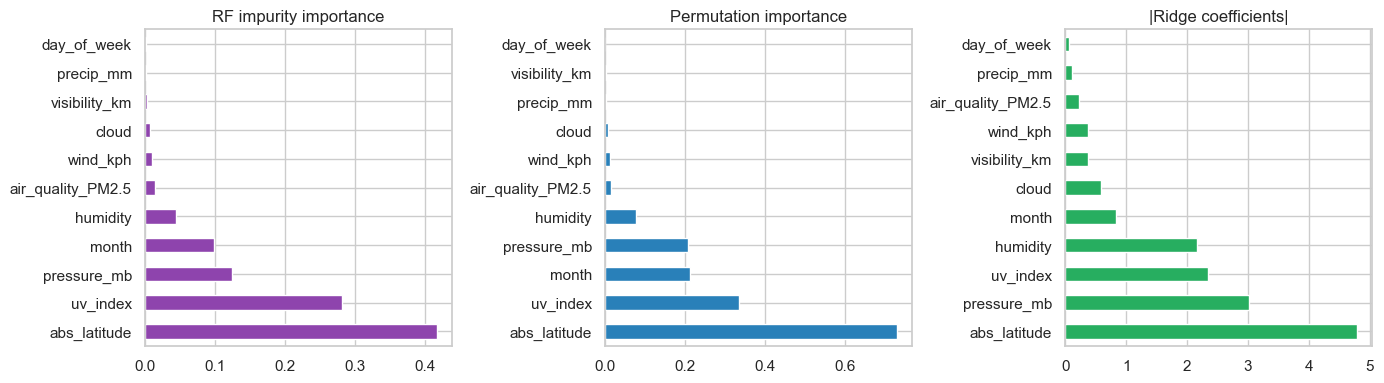

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
rf_imp.plot(kind="barh", ax=axes[0], color="#8e44ad")
axes[0].set_title("RF impurity importance")
perm_imp.plot(kind="barh", ax=axes[1], color="#2980b9")
axes[1].set_title("Permutation importance")
ridge_imp.plot(kind="barh", ax=axes[2], color="#27ae60")
axes[2].set_title("|Ridge coefficients|")
plt.tight_layout()
fig.savefig(OUT_DIR / "06_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Spatial analysis — maps of mean temperature & PM2.5

### Why
Show geographic patterns with latitude/longitude.
Each city = one point sized/colored by average condition.


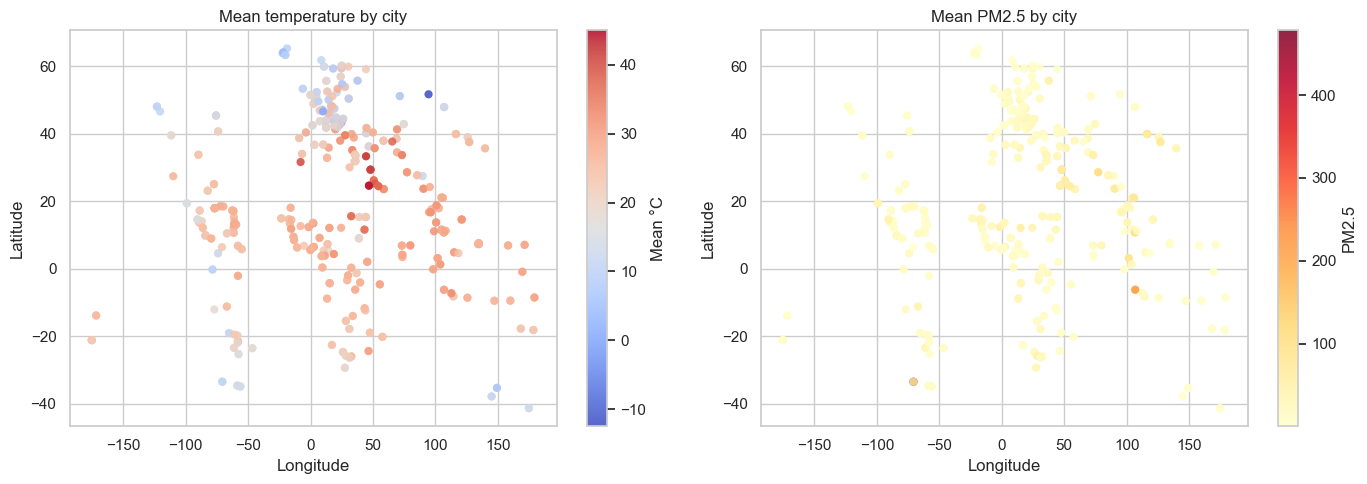

In [10]:
city_stats = (
    df.groupby(["country", "location_name", "latitude", "longitude", "continent"], as_index=False)
    .agg(
        mean_temp=("temperature_celsius", "mean"),
        mean_precip=("precip_mm", "mean"),
        mean_pm25=("air_quality_PM2.5", "mean"),
        n=("temperature_celsius", "count"),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(
    city_stats["longitude"], city_stats["latitude"],
    c=city_stats["mean_temp"], cmap="coolwarm", s=35, alpha=0.85, edgecolors="none",
)
axes[0].set_title("Mean temperature by city")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
plt.colorbar(sc0, ax=axes[0], label="Mean °C")

sc1 = axes[1].scatter(
    city_stats["longitude"], city_stats["latitude"],
    c=city_stats["mean_pm25"], cmap="YlOrRd", s=35, alpha=0.85, edgecolors="none",
)
axes[1].set_title("Mean PM2.5 by city")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
plt.colorbar(sc1, ax=axes[1], label="PM2.5")

plt.tight_layout()
fig.savefig(OUT_DIR / "07_spatial_maps.png", dpi=150, bbox_inches="tight")
plt.show()

city_stats.to_csv(OUT_DIR / "city_spatial_stats.csv", index=False)


## 7. Geographical patterns — countries & continents

Hottest / coldest / most polluted countries (enough samples for stable means).


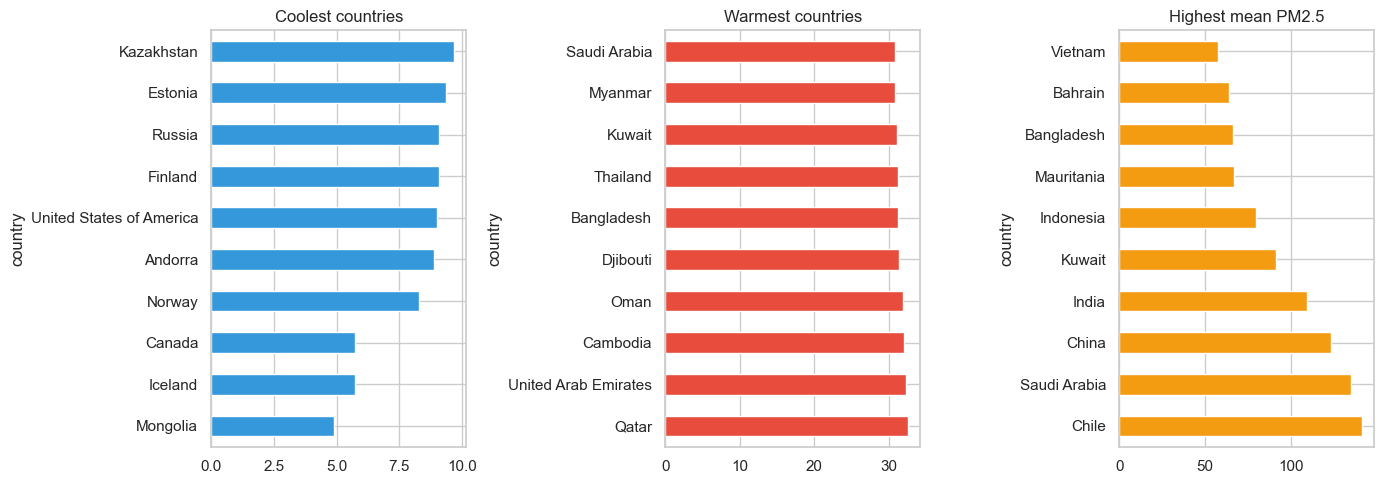

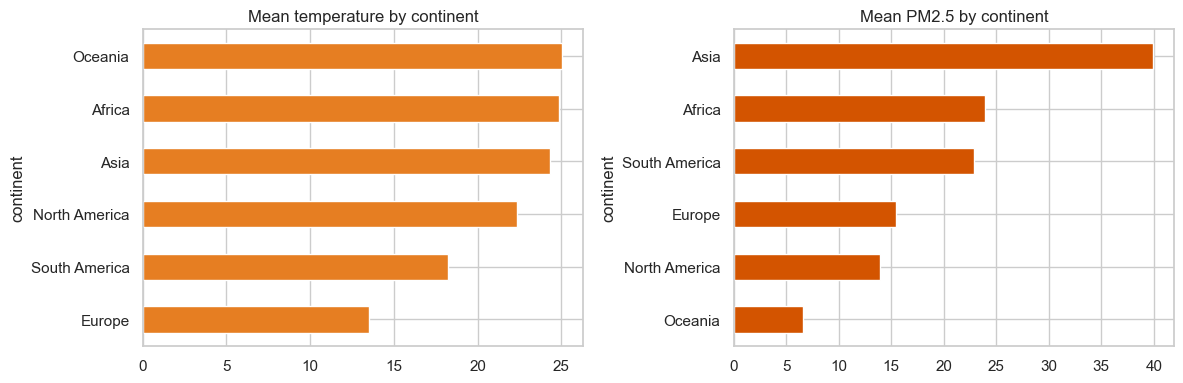

In [11]:
country_stats = (
    df.groupby(["country", "continent"], as_index=False)
    .agg(
        mean_temp=("temperature_celsius", "mean"),
        mean_precip=("precip_mm", "mean"),
        mean_pm25=("air_quality_PM2.5", "mean"),
        n=("temperature_celsius", "count"),
    )
    .query("n >= 200")
)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

country_stats.nsmallest(10, "mean_temp").set_index("country")["mean_temp"].plot(kind="barh", ax=axes[0], color="#3498db")
axes[0].set_title("Coolest countries")

country_stats.nlargest(10, "mean_temp").set_index("country")["mean_temp"].plot(kind="barh", ax=axes[1], color="#e74c3c")
axes[1].set_title("Warmest countries")

country_stats.nlargest(10, "mean_pm25").set_index("country")["mean_pm25"].plot(kind="barh", ax=axes[2], color="#f39c12")
axes[2].set_title("Highest mean PM2.5")

plt.tight_layout()
fig.savefig(OUT_DIR / "08_country_extremes.png", dpi=150, bbox_inches="tight")
plt.show()

# Continent comparison bars
cont_plot = continent_summary.drop(index="Other", errors="ignore")
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
cont_plot["mean_temp"].sort_values().plot(kind="barh", ax=axes[0], color="#e67e22")
axes[0].set_title("Mean temperature by continent")
cont_plot["mean_pm25"].sort_values().plot(kind="barh", ax=axes[1], color="#d35400")
axes[1].set_title("Mean PM2.5 by continent")
plt.tight_layout()
fig.savefig(OUT_DIR / "09_continent_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

country_stats.to_csv(OUT_DIR / "country_geo_stats.csv", index=False)


## 8. Save key insights summary


In [12]:
insights = {
    "n_rows": len(df),
    "n_continents_mapped": int(df["continent"].nunique()),
    "anomaly_rate_pct": round(100 * anom_sample["is_anomaly"].mean(), 2),
    "pm25_corr_wind": float(pm25_corr.get("wind_kph", np.nan)),
    "pm25_corr_humidity": float(pm25_corr.get("humidity", np.nan)),
    "pm25_corr_temp": float(pm25_corr.get("temperature_celsius", np.nan)),
    "top_rf_feature": rf_imp.index[0],
    "top_perm_feature": perm_imp.index[0],
    "top_ridge_feature": ridge_imp.index[0],
    "warmest_continent": continent_summary["mean_temp"].idxmax(),
    "coolest_continent": continent_summary["mean_temp"].idxmin(),
    "highest_pm25_continent": aqi_by_cont["air_quality_PM2.5"].idxmax(),
}
pd.Series(insights).to_csv(OUT_DIR / "advanced_insights.csv", header=["value"])
print("Saved outputs to:", OUT_DIR)
display(pd.Series(insights))


Saved outputs to: E:\PM Accelerator\Data Science Intern\weather-trend-forecast\outputs\advanced


n_rows                          153775
n_continents_mapped                  7
anomaly_rate_pct                   2.0
pm25_corr_wind               -0.046123
pm25_corr_humidity           -0.220724
pm25_corr_temp                0.063492
top_rf_feature            abs_latitude
top_perm_feature          abs_latitude
top_ridge_feature         abs_latitude
warmest_continent              Oceania
coolest_continent               Europe
highest_pm25_continent            Asia
dtype: object